In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pepccorpus/wiki_extracted_200k.en
/kaggle/input/pepccorpus/wiki_extracted_200k.fa
/kaggle/input/taoeba/Tatoeba.en-pes.pes
/kaggle/input/taoeba/Tatoeba.en-pes.en
/kaggle/input/taoeba/Tatoeba.en-pes.xml


<h1 style="text-align: center; font-weight: bold;">
بِسْمِ ٱللَّٰهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ
</h1>

Full Name: Mohammadmahdi Bababeyk
 
Student ID: 4041419005

# Sequence-to-Sequence Neural Machine Translation with Additive Attention

This notebook provides a comprehensive, hands-on implementation of a Sequence-to-Sequence (Seq2Seq) model with an Additive Attention mechanism for the task of Neural Machine Translation (NMT). The specific application demonstrated is translation from Persian (Farsi) to English, using a parallel corpus from the Tatoeba dataset.

**Purpose and Scope of This Notebook**

This notebook is designed as a practical, end-to-end assignment that goes beyond theoretical concepts. Its primary objectives are:

- Implementation from Scratch: To build a complete, production-ready NMT pipeline in PyTorch, including a Bidirectional GRU Encoder, a GRU Decoder, and a custom Additive (Bahdanau-style) Attention layer.

- Handling Real-World Data: To demonstrate the processing of raw parallel text data using SentencePiece for subword tokenization, which is crucial for handling vocabulary size and unknown words in both Persian and English.

- Incorporating Advanced Training Techniques: To implement practical training strategies such as delayed scheduled sampling (to transition from teacher forcing to autonomous decoding) and gradient clipping for stable optimization.

- Robust Evaluation and Inference: To showcase evaluation using a custom, safe corpus-level BLEU score calculation and a detailed beam search decoding algorithm with length normalization for generating high-quality translations.

- Model Interpretability: To provide functionality for visualizing the attention alignments between source and target tokens, offering insight into what the model "focuses on" during translation.

- Performance Benchmarking: To train the model over multiple epochs, monitor loss and BLEU score on a validation set, and save the best-performing checkpoint, illustrating the iterative development and improvement process of an NMT system.

## 0.Import Dependencies

This section imports essential Python libraries for building the Neural Machine Translation (NMT) pipeline.

In [52]:
import os
import math
import random
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt

## 1.Configuration and Hyperparameters

The following hyperparameters are carefully chosen to balance model capacity, training efficiency, and performance on the translation task, with specific considerations for the characteristics of the Persian-English language pair.

In [61]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_FA = "/kaggle/input/pepccorpus/wiki_extracted_200k.fa"   # Persian source
DATA_EN = "/kaggle/input/pepccorpus/wiki_extracted_200k.en"   # English target

MAX_LEN = 40
VOCAB_SIZE = 16000
BATCH_SIZE = 32
EMB_DIM = 512
HID_DIM = 512
EPOCHS = 60
LR = 3e-4
WINDOW = 8

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

random.seed(42)
torch.manual_seed(42)

## 2.Parallel Data Loading Function

This function serves as the first step in the data pipeline, transforming raw text files into a structured dataset suitable for machine translation training.

In [62]:
def load_parallel(fa_path, en_path, max_len):
    pairs = []
    with open(fa_path, encoding="utf-8") as f_fa, open(en_path, encoding="utf-8") as f_en:
        for fa, en in zip(f_fa, f_en):
            fa, en = fa.strip(), en.strip()
            if not fa or not en:
                continue
            if len(fa.split()) > max_len or len(en.split()) > max_len:
                continue
            pairs.append((fa, en.lower()))
    return pairs

## 3.SentencePiece Tokenizer Training Function

This function enables the creation of language-specific subword tokenizers that handle out-of-vocabulary words gracefully and maintain reasonable vocabulary sizes for efficient model training.

### Practice 1: Complete the SentencePiece Training Call

You are given a function `train_spm` that prepares training data for a SentencePiece tokenizer and is meant to train a Byte-Pair Encoding (BPE) model using the `sentencepiece` library.

In [38]:
def train_spm(sentences, prefix, vocab_size):
    """
    Train a SentencePiece tokenizer model on the provided sentences.

    This function creates a temporary file with the training sentences and
    trains a Byte-Pair Encoding (BPE) tokenizer using the SentencePiece library.

    Args:
        sentences (list): List of text sentences to train the tokenizer on.
        prefix (str): Prefix for the output model files. The function will create
                      files named `{prefix}.model` and `{prefix}.vocab`.
        vocab_size (int): Desired vocabulary size for the tokenizer.

    Returns:
        None: The function saves the trained model to disk.

    Notes:
        - Uses BPE (Byte-Pair Encoding) as the segmentation algorithm.
        - Configures special token IDs (PAD, BOS, EOS, UNK) from global constants.
        - Creates a temporary file for training data that is automatically managed.
    """
    # TODO: Complete the following function call
    with open("temp_train.txt", "w", encoding="utf-8") as f:
        for sent in sentences:
            f.write(sent + "\n")

    # Train the BPE model
    spm.SentencePieceTrainer.train(
        input="temp_train.txt",
        model_prefix=prefix,
        vocab_size=vocab_size,
        model_type="bpe",
        pad_id=PAD_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
        unk_id=UNK_ID
    )
    
    # Clean up
    if os.path.exists("temp_train.txt"):
        os.remove("temp_train.txt")

## 4.Dataset

In [64]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, sp_src, sp_tgt):
        self.pairs = pairs
        self.sp_src = sp_src
        self.sp_tgt = sp_tgt

    def encode(self, sp, text):
        ids = [BOS_ID] + sp.encode(text, out_type=int)[: MAX_LEN - 2] + [EOS_ID]
        return torch.tensor(ids)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        fa, en = self.pairs[idx]
        return self.encode(self.sp_src, fa), self.encode(self.sp_tgt, en)


def collate_fn(batch):
    src, tgt = zip(*batch)
    src = nn.utils.rnn.pad_sequence(src, padding_value=PAD_ID)
    tgt = nn.utils.rnn.pad_sequence(tgt, padding_value=PAD_ID)
    return src.to(DEVICE), tgt.to(DEVICE)

### Practice 2: Explain what does `TranslationDataset` class do.

## 5.Encoder

This class implements a bidirectional GRU-based encoder commonly used in sequence-to-sequence (seq2seq) models (e.g., for machine translation or text summarization).

### Practice 3: Complete the missing lines in the Encoder class below.

You are given the class structure and docstring — fill in:

1. The embedding layer initialization in __init__,  
2. The GRU layer initialization,  
3. The forward pass logic (embedding + GRU).

Use the following global constants (assume they’re defined):  

- EMB_DIM: embedding dimension  
- HID_DIM: hidden dimension  
- PAD_ID: padding token ID

In [40]:
class Encoder(nn.Module):
    """
    A bidirectional GRU-based encoder for sequence-to-sequence models.

    Takes a sequence of token IDs (time-major) and returns contextualized
    representations and final hidden states.
    """

    def __init__(self, vocab):
        super().__init__()
        # TODO 1: Initialize embedding layer
        self.emb = nn.Embedding(vocab, EMB_DIM, padding_idx=PAD_ID)

        # TODO 2: Initialize bidirectional GRU
        self.gru = nn.GRU(EMB_DIM, HID_DIM, bidirectional=True)

    def forward(self, src):
        """
        Args:
            src (Tensor): shape (seq_len, batch_size)

        Returns:
            out (Tensor): shape (seq_len, batch_size, 2 * HID_DIM)
            hid (Tensor): shape (2, batch_size, HID_DIM)
        """
        # TODO 3: Compute embeddings and pass through GRU
        emb = self.emb(src) 
        out, hid = self.gru(emb)
        return out, hid

## 6.Additive Attention

The `AdditiveAttention` class implements the Bahdanau-style additive attention mechanism with a local window constraint. This module enables the decoder to dynamically focus on relevant parts of the source sentence during translation generation.

### Practice 4: Complete the missing parts inside the forward method of the AdditiveAttention class.

You are given the setup and window slicing — fill in:

1. Expansion of dec to match enc_slice in time dimension,  
2. The attention scoring computation using self.W_h, self.W_s, self.v, and torch.tanh,  
3. Softmax normalization over the time (window) dimension,  
4. Context vector as a weighted sum.

In [41]:
class AdditiveAttention(nn.Module):
    """
    Additive (Bahdanau) attention with local windowing.

    Computes attention over a fixed-size window of encoder outputs centered
    around decoder timestep `t`, reducing computational cost and encouraging
    local focus.

    The alignment score for encoder state h_i and decoder state s_t is:
        e_i = v^T tanh(W_h h_i + W_s s_t)

    Assumes:
        - Encoder is bidirectional → hidden size = 2 * HID_DIM
        - Inputs are time-major (seq_len, batch, dim)

    Attributes:
        W_h (nn.Linear): Projects encoder states (2*HID_DIM → HID_DIM)
        W_s (nn.Linear): Projects decoder state (2*HID_DIM → HID_DIM)
        v (nn.Linear): Scoring vector (HID_DIM → 1, no bias)
    """

    def __init__(self):
        super().__init__()
        self.W_h = nn.Linear(2 * HID_DIM, HID_DIM)
        self.W_s = nn.Linear(2 * HID_DIM, HID_DIM)
        self.v = nn.Linear(HID_DIM, 1, bias=False)

    def forward(self, enc_out, dec_state, t):
        """
        Compute context vector using local additive attention.

        Args:
            enc_out (Tensor): Encoder outputs, shape `(T, batch_size, 2 * HID_DIM)`.
            dec_state (Tensor): Current decoder hidden state, shape `(1, batch_size, 2 * HID_DIM)`.
            t (int): Current decoder timestep (0-indexed).

        Returns:
            ctx (Tensor): Context vector, shape `(batch_size, 2 * HID_DIM)`.
            alpha (Tensor): Attention weights over window, shape `(window_len, batch_size)`.
            start (int): Start index of attention window in encoder sequence.
            end (int): End index (exclusive) of attention window.
        """
        T = enc_out.size(0)
        start = max(0, t - WINDOW // 2)
        end = min(T, start + WINDOW)

        enc_slice = enc_out[start:end]           
        dec = dec_state.squeeze(0)               
        
        # TODO 1: Expand decoder state to match encoder slice time dim
        dec_exp = dec.unsqueeze(0).expand(enc_slice.size(0), -1, -1)

        # TODO 2: Compute alignment scores e (window_len, B)
        e = self.v(torch.tanh(self.W_h(enc_slice) + self.W_s(dec_exp)))
        e = e.squeeze(-1)  

        # TODO 3: Normalize scores
        alpha = F.softmax(e, dim=0)

        # TODO 4: Compute context vector ctx
        ctx = (alpha.unsqueeze(-1) * enc_slice).sum(dim=0)

        return ctx, alpha, start, end

## 7.Decoder

The Decoder class implements the generation component of the Seq2Seq model, responsible for producing the English translation token-by-token while leveraging the encoder's representations and attention mechanism.

### Practice 5: Complete the Decoder's `forward` Method
You are implementing an attentional GRU decoder for a seq2seq model.
The `__init__` and docstring are provided. Your task is to fill in the missing logic inside the decoding loop.

In [42]:
class Decoder(nn.Module):
    """
    GRU-based attentional decoder for sequence-to-sequence models.

    Uses teacher forcing during training and greedy decoding during inference.
    At each step, computes an attention context vector using `self.attn`,
    concatenates it with the input embedding, and passes through a GRU.

    Input/Output Convention:
        - All sequences are time-major: (seq_len, batch_size)
        - `tgt[0]` should be the BOS token.

    Args:
        vocab (int): Output vocabulary size.
        attn (nn.Module): Attention module (e.g., AdditiveAttention) with
                          forward(enc_out, dec_hid, t) → (ctx, ...).

    Attributes:
        emb (nn.Embedding): Token embeddings (vocab → EMB_DIM).
        gru (nn.GRU): Processes [embedding; context], hidden size = 2 * HID_DIM.
        fc (nn.Linear): Maps [GRU output; context] (4 * HID_DIM) → logits (vocab).
        attn (nn.Module): Attention module.
    """

    def __init__(self, vocab, attn):
        super().__init__()
        self.emb = nn.Embedding(vocab, EMB_DIM, padding_idx=PAD_ID)
        self.gru = nn.GRU(EMB_DIM + 2 * HID_DIM, 2 * HID_DIM)
        self.fc = nn.Linear(4 * HID_DIM, vocab)
        self.attn = attn

    def forward(self, tgt, enc_out, hid, tf_ratio=1.0):
        """
        Forward pass with optional teacher forcing.

        Args:
            tgt (Tensor): Target sequence, shape `(T, batch_size)`, where `tgt[0]`
                          is assumed to be the BOS token.
            enc_out (Tensor): Encoder outputs, shape `(S, batch_size, 2 * HID_DIM)`.
            hid (Tensor): Initial decoder hidden state, shape `(1, batch_size, 2 * HID_DIM)`.
            tf_ratio (float): Probability of using teacher forcing (1.0 = always GT).

        Returns:
            outputs (Tensor): Logits for steps 1 to T−1, shape `(T−1, batch_size, vocab)`.
        """
        outputs = []
        inp = tgt[0]  

        for t in range(1, tgt.size(0)):
            # TODO 1: Embedding with time dimension
            emb = self.emb(inp).unsqueeze(0)

            # TODO 2: Attention context
            ctx, _, _, _ = self.attn(enc_out, hid, t)

            # TODO 3: Concatenate embedding and context
            gru_in = torch.cat([emb, ctx.unsqueeze(0)], dim=-1)

            # TODO 4: Run GRU
            out, hid = self.gru(gru_in, hid)

            # TODO 5: Compute logits
            logits = self.fc(torch.cat([out.squeeze(0), ctx], dim=-1))
            outputs.append(logits)

            # TODO 6: Teacher forcing logic
            teacher = random.random() < tf_ratio
            inp = tgt[t] if teacher else logits.argmax(-1)

        return torch.stack(outputs)

## 8.Seq2Seq

The `Seq2Seq` class serves as a container and coordinator that integrates the Encoder and Decoder components into a complete, end-to-end neural machine translation system.

In [43]:
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def forward(self, src, tgt, tf_ratio):
        enc_out, enc_h = self.enc(src)
        h = torch.cat([enc_h[0], enc_h[1]], dim=-1).unsqueeze(0)
        return self.dec(tgt, enc_out, h, tf_ratio)

## 9.Training

In [44]:
def train_epoch(model, loader, optim, criterion, tf_ratio):
    model.train()
    total = 0
    for src, tgt in loader:
        optim.zero_grad()
        out = model(src, tgt, tf_ratio)
        loss = criterion(out.reshape(-1, out.size(-1)), tgt[1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        total += loss.item()
    return total / len(loader)

In [47]:
if __name__ == "__main__":
    # Load data
    pairs = load_parallel(DATA_FA, DATA_EN, MAX_LEN)
    random.shuffle(pairs)

    train_pairs = pairs[:4000]
    val_pairs = pairs[4000:4800]

    # Train SentencePiece (once)
    if not os.path.exists("sp_fa.model"):
        train_spm([p[0] for p in train_pairs], "sp_fa", VOCAB_SIZE)
    if not os.path.exists("sp_en.model"):
        train_spm([p[1] for p in train_pairs], "sp_en", VOCAB_SIZE)

    sp_fa = spm.SentencePieceProcessor(model_file="sp_fa.model")
    sp_en = spm.SentencePieceProcessor(model_file="sp_en.model")

    train_ds = TranslationDataset(train_pairs, sp_fa, sp_en)
    val_ds = TranslationDataset(val_pairs, sp_fa, sp_en)

    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    enc = Encoder(len(sp_fa))
    attn = AdditiveAttention()
    dec = Decoder(len(sp_en), attn)
    model = Seq2Seq(enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    best_bleu = 0.0

    for epoch in range(1, EPOCHS + 1):
        tf_ratio = 1.0 if epoch < 10 else max(0.7, 1 - (epoch - 10) / (EPOCHS - 10))
        loss = train_epoch(model, train_loader, optimizer, criterion, tf_ratio)

        # BLEU evaluation
        model.eval()
        hyps, refs = [], []
        with torch.no_grad():
            for src, tgt in val_loader:
                for i in range(src.size(1)):
                    sent = sp_fa.decode(src[:, i].tolist())
                    pred, _, _ = translate_with_attention(model, sent, sp_fa, sp_en)
                    ref = sp_en.decode(tgt[:, i].tolist())
                    if len(pred.split()) > 0:
                        hyps.append(pred.split())
                        refs.append([ref.split()])

        bleu = corpus_bleu(hyps, refs)
        print(f"Epoch {epoch}: Loss={loss:.4f}, BLEU={bleu:.4f}")

        if bleu > best_bleu:
            best_bleu = bleu
            torch.save(model.state_dict(), "best_fa_en_model.pt")
            print("Best model saved")

Epoch 1: Loss=5.6879, BLEU=0.0000
Best model saved
Epoch 2: Loss=4.3741, BLEU=0.0000
Best model saved
Epoch 3: Loss=3.7894, BLEU=0.0171
Best model saved
Epoch 4: Loss=3.2873, BLEU=0.0210
Best model saved
Epoch 5: Loss=2.8235, BLEU=0.0263
Best model saved
Epoch 6: Loss=2.3945, BLEU=0.0287
Best model saved
Epoch 7: Loss=2.0029, BLEU=0.0315
Best model saved
Epoch 8: Loss=1.6493, BLEU=0.0360
Best model saved
Epoch 9: Loss=1.3409, BLEU=0.0465
Best model saved
Epoch 10: Loss=1.0774, BLEU=0.0537
Best model saved
Epoch 11: Loss=0.8679, BLEU=0.0565
Best model saved
Epoch 12: Loss=0.6960, BLEU=0.0585
Best model saved
Epoch 13: Loss=0.5573, BLEU=0.0617
Best model saved
Epoch 14: Loss=0.4267, BLEU=0.0658
Best model saved
Epoch 15: Loss=0.3258, BLEU=0.0685
Best model saved
Epoch 16: Loss=0.2512, BLEU=0.0613
Epoch 17: Loss=0.1972, BLEU=0.0645
Epoch 18: Loss=0.1582, BLEU=0.0655
Epoch 19: Loss=0.1227, BLEU=0.0655
Epoch 20: Loss=0.1003, BLEU=0.0634
Epoch 21: Loss=0.0884, BLEU=0.0723
Best model saved
Ep

## 10.BLEU

BLEU is an automatic evaluation metric for machine translation that compares machine-generated translations (hypotheses) against human reference translations. It was introduced in 2002 by IBM researchers and has become the standard automatic metric for evaluating translation quality.

In [70]:
def corpus_bleu(hyps, refs, max_n=4):
    """
    Calculate BLEU score for a corpus of translations.

    Args:
        hyps (list): List of hypotheses, each as list of tokens
        refs (list): List of references, each as list of list of tokens
        max_n (int): Maximum n-gram order (default: 4)

    Returns:
        float: BLEU score
    """
    if len(hyps) == 0:
        return 0.0

    weights = [1 / max_n] * max_n
    score = 0.0

    for n in range(1, max_n + 1):
        num, denom = 0, 0
        for h, r in zip(hyps, refs):
            h_ngrams = Counter([tuple(h[i:i+n]) for i in range(len(h)-n+1)])
            r_ngrams = Counter([tuple(r[0][i:i+n]) for i in range(len(r[0])-n+1)])
            num += sum((h_ngrams & r_ngrams).values())
            denom += max(1, sum(h_ngrams.values()))
        score += weights[n-1] * math.log((num + 1e-9) / denom)

    bp = math.exp(1 - max(1, sum(len(h) for h in hyps) / max(1, sum(len(r[0]) for r in refs))))
    return bp * math.exp(score)

## 11.Inference + Attention

In [71]:
def translate_with_attention(model, sentence, sp_src, sp_tgt, max_len=40, min_len=3):
    """
    Translate a single sentence with attention visualization.

    Args:
        model: Seq2Seq model
        sentence (str): Source sentence
        sp_src: Source language tokenizer
        sp_tgt: Target language tokenizer
        max_len (int): Maximum translation length
        min_len (int): Minimum translation length

    Returns:
        translation (str): Translated sentence
        src_tokens (list): Source tokens
        attn (numpy array): Attention weights
    """
    model.eval()
    attentions = []

    with torch.no_grad():
        # Encode source sentence
        src_ids = [BOS_ID] + sp_src.encode(sentence, out_type=int)[:max_len-2] + [EOS_ID]
        src = torch.tensor(src_ids, device=DEVICE).unsqueeze(1)
        src_tokens = ["<bos>"] + sp_src.encode(sentence, out_type=str) + ["<eos>"]

        # Encode with encoder
        enc_out, enc_h = model.enc(src)
        hid = torch.cat([enc_h[0], enc_h[1]], dim=-1).unsqueeze(0)

        # Start decoding with BOS token
        inp = torch.tensor([BOS_ID], device=DEVICE)
        out_tokens = []

        for t in range(max_len):
            # Get embedding
            emb = model.dec.emb(inp).unsqueeze(0)

            # Compute attention
            ctx, alpha, s, e = model.dec.attn(enc_out, hid, t)
            full_alpha = torch.zeros(enc_out.size(0))
            full_alpha[s:e] = alpha.squeeze().cpu()
            attentions.append(full_alpha)

            # Decode one step
            gru_in = torch.cat([emb, ctx.unsqueeze(0)], dim=-1)
            out, hid = model.dec.gru(gru_in, hid)
            logits = model.dec.fc(torch.cat([out.squeeze(0), ctx], dim=-1))
            pred = logits.argmax(-1).item()

            # Stop if EOS token and minimum length reached
            if pred == EOS_ID and t >= min_len:
                break
            out_tokens.append(pred)
            inp = torch.tensor([pred], device=DEVICE)

    return sp_tgt.decode(out_tokens), src_tokens, torch.stack(attentions).numpy()


def plot_attention(src_tokens, tgt_sentence, attn):
    """
    Plot attention alignment between source and target tokens.

    Args:
        src_tokens (list): Source tokens
        tgt_sentence (str): Target sentence
        attn (numpy array): Attention weights matrix
    """
    tgt_tokens = tgt_sentence.split()
    attn = attn[:len(tgt_tokens)]

    plt.figure(figsize=(len(src_tokens)*0.4, len(tgt_tokens)*0.4))
    plt.imshow(attn, aspect="auto", cmap="viridis")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=90)
    plt.yticks(range(len(tgt_tokens)), tgt_tokens)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

## 12.Load & Evaluate the Model

In [48]:
# Load best checkpoint
enc = Encoder(len(sp_fa))
attn = AdditiveAttention()
dec = Decoder(len(sp_en), attn)
model = Seq2Seq(enc, dec).to(DEVICE)

model.load_state_dict(torch.load("best_fa_en_model.pt", map_location=DEVICE))
model.eval()

print("Model loaded")

Model loaded


In [49]:
fa_sentence = "نمی دانم وقت خواهم داشت یا نه."

translation, src_tokens, attn = translate_with_attention(
    model,
    fa_sentence,
    sp_fa,
    sp_en
)

print("Translation:", translation)

Translation: i don't know if i have the time,.


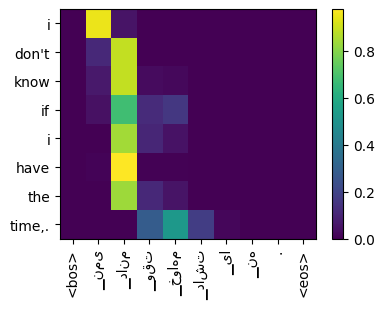

In [50]:
plot_attention(src_tokens, translation, attn)

### **Bonus**

Choose a larger Fa–En translation dataset, adapt the above code accordingly, and submit a report containing the following sections:

**Report Structure:**

1. **Introduction**  
    - Problem Statement  
    - Dataset Description and Motivation  
    - Objectives  

2. **Methodology**  
    - Data Preprocessing Steps  
    - Model Architecture (including a diagram)  
    - Modifications Made to the Original Code  
    - Training Procedure  

3. **Experimental Setup**    
    - Hyperparameter Settings  
    - Evaluation Metrics  

4. **Results**  
    - Quantitative Results (BLEU scores, presented in a table)  
    - Qualitative Examples (showcasing both successful and erroneous translations)  
    - Attention Visualizations  

**Bonus Criterion:**  
     To earn the full bonus, the model must achieve a **BLEU score of at least 0.20**

In [63]:
def train_spm(sentences, prefix, vocab_size):
    """
    Train a SentencePiece tokenizer model on the provided sentences.
    """
    # Create a temporary file to store sentences for the trainer
    with open("temp_train.txt", "w", encoding="utf-8") as f:
        for sent in sentences:
            f.write(sent + "\n")

    # TODO: Complete the following function call
    spm.SentencePieceTrainer.train(
        input="temp_train.txt",
        model_prefix=prefix,
        vocab_size=vocab_size,
        model_type="bpe",
        pad_id=PAD_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
        unk_id=UNK_ID
    )
    
    # Cleanup temporary file
    if os.path.exists("temp_train.txt"):
        os.remove("temp_train.txt")

In [65]:
class Encoder(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        # TODO 1: Initialize embedding layer
        self.emb = nn.Embedding(vocab, EMB_DIM, padding_idx=PAD_ID)

        # TODO 2: Initialize bidirectional GRU
        self.gru = nn.GRU(EMB_DIM, HID_DIM, bidirectional=True)

    def forward(self, src):
        # TODO 3: Compute embeddings and pass through GRU
        emb = self.emb(src) 
        out, hid = self.gru(emb)
        return out, hid

In [66]:
class AdditiveAttention(nn.Module):
    """
    Additive (Bahdanau) attention with local windowing.

    Computes attention over a fixed-size window of encoder outputs centered
    around decoder timestep `t`, reducing computational cost and encouraging
    local focus.

    The alignment score for encoder state h_i and decoder state s_t is:
        e_i = v^T tanh(W_h h_i + W_s s_t)

    Assumes:
        - Encoder is bidirectional → hidden size = 2 * HID_DIM
        - Inputs are time-major (seq_len, batch, dim)

    Attributes:
        W_h (nn.Linear): Projects encoder states (2*HID_DIM → HID_DIM)
        W_s (nn.Linear): Projects decoder state (2*HID_DIM → HID_DIM)
        v (nn.Linear): Scoring vector (HID_DIM → 1, no bias)
    """

    def __init__(self):
        super().__init__()
        self.W_h = nn.Linear(2 * HID_DIM, HID_DIM)
        self.W_s = nn.Linear(2 * HID_DIM, HID_DIM)
        self.v = nn.Linear(HID_DIM, 1, bias=False)

    def forward(self, enc_out, dec_state, t):
        T = enc_out.size(0)
        start = max(0, t - WINDOW // 2)
        end = min(T, start + WINDOW)

        enc_slice = enc_out[start:end]           # (window_len, B, 2H)
        dec = dec_state.squeeze(0)               # (B, 2H)
        
        # TODO 1: Expand decoder state to match encoder slice time dim
        dec_exp = dec.unsqueeze(0).expand(enc_slice.size(0), -1, -1)

        # TODO 2: Compute alignment scores e (window_len, B)
        e = self.v(torch.tanh(self.W_h(enc_slice) + self.W_s(dec_exp)))
        e = e.squeeze(-1)

        # TODO 3: Normalize scores → attention weights alpha
        alpha = F.softmax(e, dim=0)

        # TODO 4: Compute context vector ctx (B, 2H)
        ctx = (alpha.unsqueeze(-1) * enc_slice).sum(dim=0)

        return ctx, alpha, start, end

In [67]:
class Decoder(nn.Module):
    """
    GRU-based attentional decoder for sequence-to-sequence models.

    Uses teacher forcing during training and greedy decoding during inference.
    At each step, computes an attention context vector using `self.attn`,
    concatenates it with the input embedding, and passes through a GRU.

    Input/Output Convention:
        - All sequences are time-major: (seq_len, batch_size)
        - `tgt[0]` should be the BOS token.

    Args:
        vocab (int): Output vocabulary size.
        attn (nn.Module): Attention module (e.g., AdditiveAttention) with
                          forward(enc_out, dec_hid, t) → (ctx, ...).

    Attributes:
        emb (nn.Embedding): Token embeddings (vocab → EMB_DIM).
        gru (nn.GRU): Processes [embedding; context], hidden size = 2 * HID_DIM.
        fc (nn.Linear): Maps [GRU output; context] (4 * HID_DIM) → logits (vocab).
        attn (nn.Module): Attention module.
    """

    def __init__(self, vocab, attn):
        super().__init__()
        self.emb = nn.Embedding(vocab, EMB_DIM, padding_idx=PAD_ID)
        self.gru = nn.GRU(EMB_DIM + 2 * HID_DIM, 2 * HID_DIM)
        self.fc = nn.Linear(4 * HID_DIM, vocab)
        self.attn = attn

    def forward(self, tgt, enc_out, hid, tf_ratio=1.0):
        outputs = []
        inp = tgt[0]  

        for t in range(1, tgt.size(0)):
            # TODO 1: Embedding with time dimension
            emb = self.emb(inp).unsqueeze(0)

            # TODO 2: Compute attention context
            ctx, _, _, _ = self.attn(enc_out, hid, t)

            # TODO 3: Concatenate embedding and context
            gru_in = torch.cat([emb, ctx.unsqueeze(0)], dim=-1)

            # TODO 4: Run GRU
            out, hid = self.gru(gru_in, hid)

            # TODO 5: Compute logits
            logits = self.fc(torch.cat([out.squeeze(0), ctx], dim=-1))
            outputs.append(logits)

            # TODO 6: Teacher forcing
            teacher = random.random() < tf_ratio
            inp = tgt[t] if teacher else logits.argmax(-1)

        return torch.stack(outputs)

In [68]:
class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def forward(self, src, tgt, tf_ratio):
        enc_out, enc_h = self.enc(src)
        h = torch.cat([enc_h[0], enc_h[1]], dim=-1).unsqueeze(0)
        return self.dec(tgt, enc_out, h, tf_ratio)

In [69]:
def train_epoch(model, loader, optim, criterion, tf_ratio):
    model.train()
    total = 0
    for src, tgt in loader:
        optim.zero_grad()
        out = model(src, tgt, tf_ratio)
        loss = criterion(out.reshape(-1, out.size(-1)), tgt[1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        total += loss.item()
    return total / len(loader)

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).

In [72]:
if __name__ == "__main__":
    # Load data
    pairs = load_parallel(DATA_FA, DATA_EN, MAX_LEN)
    random.shuffle(pairs)

    train_pairs = pairs[:4000]
    val_pairs = pairs[4000:4800]

    # Train SentencePiece (once)
    if not os.path.exists("sp_fa.model"):
        train_spm([p[0] for p in train_pairs], "sp_fa", VOCAB_SIZE)
    if not os.path.exists("sp_en.model"):
        train_spm([p[1] for p in train_pairs], "sp_en", VOCAB_SIZE)

    sp_fa = spm.SentencePieceProcessor(model_file="sp_fa.model")
    sp_en = spm.SentencePieceProcessor(model_file="sp_en.model")

    train_ds = TranslationDataset(train_pairs, sp_fa, sp_en)
    val_ds = TranslationDataset(val_pairs, sp_fa, sp_en)

    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    enc = Encoder(len(sp_fa))
    attn = AdditiveAttention()
    dec = Decoder(len(sp_en), attn)
    model = Seq2Seq(enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

    best_bleu = 0.0

    for epoch in range(1, EPOCHS + 1):
        tf_ratio = 1.0 if epoch < 10 else max(0.7, 1 - (epoch - 10) / (EPOCHS - 10))
        loss = train_epoch(model, train_loader, optimizer, criterion, tf_ratio)

        # BLEU evaluation
        model.eval()
        hyps, refs = [], []
        with torch.no_grad():
            for src, tgt in val_loader:
                for i in range(src.size(1)):
                    sent = sp_fa.decode(src[:, i].tolist())
                    pred, _, _ = translate_with_attention(model, sent, sp_fa, sp_en)
                    ref = sp_en.decode(tgt[:, i].tolist())
                    if len(pred.split()) > 0:
                        hyps.append(pred.split())
                        refs.append([ref.split()])

        bleu = corpus_bleu(hyps, refs)
        print(f"Epoch {epoch}: Loss={loss:.4f}, BLEU={bleu:.4f}")

        if bleu > best_bleu:
            best_bleu = bleu
            torch.save(model.state_dict(), "best_fa_en_model2.pt")
            print("Best model saved")

Epoch 1: Loss=7.0396, BLEU=0.0024
Best model saved
Epoch 2: Loss=6.1640, BLEU=0.0155
Best model saved
Epoch 3: Loss=5.5170, BLEU=0.0171
Best model saved
Epoch 4: Loss=4.9341, BLEU=0.0204
Best model saved
Epoch 5: Loss=4.3669, BLEU=0.0237
Best model saved
Epoch 6: Loss=3.7994, BLEU=0.0232
Epoch 7: Loss=3.2675, BLEU=0.0253
Best model saved
Epoch 8: Loss=2.7887, BLEU=0.0266
Best model saved


KeyboardInterrupt: 